# 03 — Returns and Discount Factor
**Week 3 | RL Fundamentals**

The **return** G_t is the cumulative reward from time t onwards:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

The discount factor γ ∈ [0,1) controls how much the agent cares about future rewards.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Computing Returns

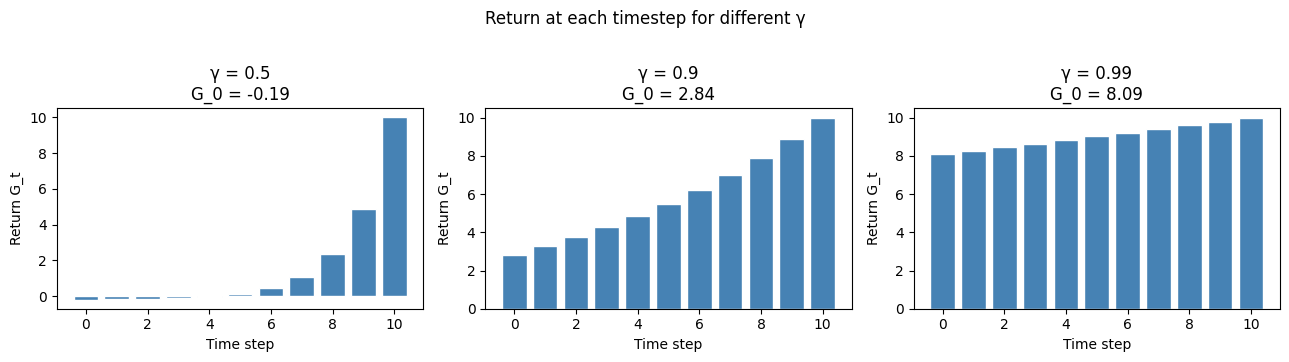

In [3]:
def compute_returns(rewards, gamma):
    """Compute discounted returns for a list of rewards (backwards pass)."""
    G = np.zeros(len(rewards))
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        G[t] = running
    return G

# Example trajectory: -0.1 per step, +10 at end
rewards = [-0.1] * 10 + [10.0]
t = np.arange(len(rewards))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, gamma in zip(axes, [0.5, 0.9, 0.99]):
    G = compute_returns(rewards, gamma)
    ax.bar(t, G, color='steelblue', edgecolor='white')
    ax.set_title(f'γ = {gamma}\nG_0 = {G[0]:.2f}')
    ax.set_xlabel('Time step'); ax.set_ylabel('Return G_t')
plt.suptitle('Return at each timestep for different γ', y=1.02)
plt.tight_layout(); plt.show()

## 2. Effect of γ on Discount Weights

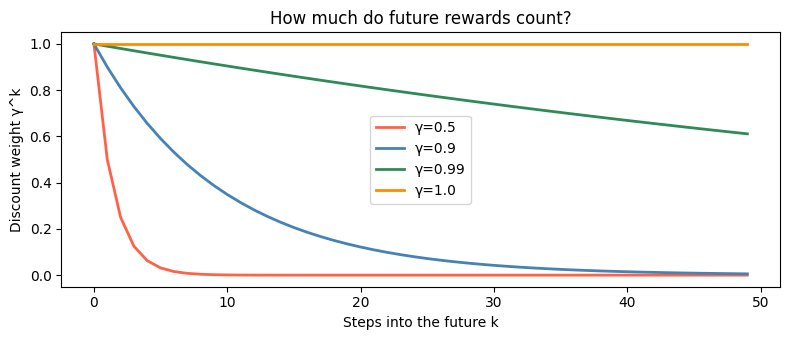


A reward 20 steps away is worth:
  γ=0.5: 0.0000 of its face value
  γ=0.9: 0.1216 of its face value
  γ=0.99: 0.8179 of its face value
  γ=1.0: 1.0000 of its face value


In [4]:
steps = np.arange(0, 50)
fig, ax = plt.subplots(figsize=(8, 3.5))
for gamma, color in [(0.5,'tomato'),(0.9,'steelblue'),(0.99,'seagreen'),(1.0,'darkorange')]:
    weights = gamma ** steps
    ax.plot(steps, weights, label=f'γ={gamma}', linewidth=2, color=color)
ax.set_xlabel('Steps into the future k')
ax.set_ylabel('Discount weight γ^k')
ax.set_title('How much do future rewards count?')
ax.legend(); plt.tight_layout(); plt.show()
print("\nA reward 20 steps away is worth:")
for g in [0.5, 0.9, 0.99, 1.0]:
    print(f"  γ={g}: {g**20:.4f} of its face value")

## 3. Episodic vs Continuing Tasks

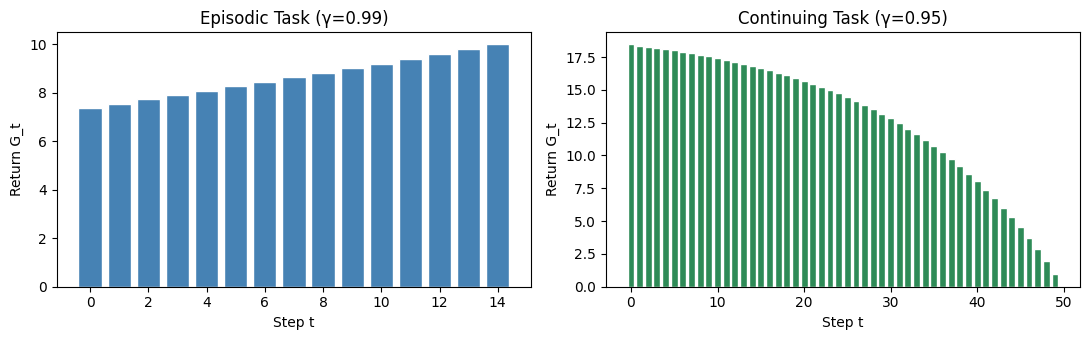

Continuing task: geometric series limit = R/(1-γ) = 20.0
Empirical G_0 = 18.46


In [5]:
# Episodic: trajectory has a natural end (e.g. reaching the goal)
def episodic_returns(n_steps=15, goal_reward=10.0, step_cost=-0.1, gamma=0.99):
    rewards = [step_cost] * (n_steps-1) + [goal_reward]
    return compute_returns(rewards, gamma)

# Continuing: no terminal state; must use discounting to keep G finite
def continuing_returns(n_steps=50, reward_per_step=1.0, gamma=0.95):
    rewards = [reward_per_step] * n_steps
    return compute_returns(rewards, gamma)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
g_ep = episodic_returns()
axes[0].bar(range(len(g_ep)), g_ep, color='steelblue', edgecolor='white')
axes[0].set_title('Episodic Task (γ=0.99)')
axes[0].set_xlabel('Step t'); axes[0].set_ylabel('Return G_t')

g_cont = continuing_returns()
axes[1].bar(range(len(g_cont)), g_cont, color='seagreen', edgecolor='white')
axes[1].set_title('Continuing Task (γ=0.95)')
axes[1].set_xlabel('Step t'); axes[1].set_ylabel('Return G_t')
plt.tight_layout(); plt.show()

print(f"Continuing task: geometric series limit = R/(1-γ) = {1.0/(1-0.95):.1f}")
print(f"Empirical G_0 = {g_cont[0]:.2f}")

## 4. The Bellman Equation for Returns
G_t = R_{t+1} + γ * G_{t+1}  — the key recursive structure used by all RL algorithms.

In [6]:
rewards = np.random.randn(20)  # random rewards
gamma   = 0.9
G = compute_returns(rewards, gamma)

# Verify Bellman equation: G[t] == rewards[t+1] + gamma * G[t+1]
for t in range(len(G)-1):
    lhs = G[t]
    rhs = rewards[t] + gamma * G[t+1]
    assert np.isclose(lhs, rhs), f"Mismatch at t={t}: {lhs:.4f} vs {rhs:.4f}"
print("✅ Bellman equation verified for all timesteps")

✅ Bellman equation verified for all timesteps


## ✅ Exercises
1. Set γ=0 and γ=1 and describe what kind of agent each creates. Is γ=1 ever safe for a continuing task?
2. Compute the optimal γ for a task where rewards are [1, 1, 1, ..., 100] after 50 steps. At what γ does the far reward contribute at least 50% of G_0?
3. **Challenge**: implement `compute_returns_forward` — compute G_t without reversing the array (hint: use the geometric series formula).

## Question 1.

## test γ=0 .

In [9]:
rewards = [-0.1] * 10 + [10.0]
G_0 = compute_returns(rewards, gamma=0)
print("γ=0 returns:", np.round(G_0, 2))

γ=0 returns: [-0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 10. ]


## test γ=1 .

In [10]:
G_1 = compute_returns(rewards, gamma=1)
print("γ=1 returns:", np.round(G_1, 2))

γ=1 returns: [ 9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7  9.8  9.9 10. ]


With γ=0, G_0 is just the immediate reward, nothing else. You can see it in the output every step shows -0.1 except the last one which shows 10, which matches exactly what the actual reward was at that step. So future stuff has zero effect. This basically makes a short sighted agent that only cares about right now.

With γ=1, G_1 shows the full future with no discounting. The output goes 9, 9.1, 9.2... all the way to 10 at the end. basically the +10 reward at the end counts in full no matter how far away it is, it just goes down a tiny bit each step because of the -0.1 cost of getting there. so this makes a fully far sighted agent, future reward = present reward, no difference.

γ=1 works fine here since this episode actually ends after 11 steps. but it wouldnt be safe for a continuing task that never ends, bcz then we be adding up infinite rewards with nothing shrinking them, and it could just blow up to infinity unless rewards average out to exactly 0.

## Question 2 .

In [11]:
rewards_q2 = [1] * 50 + [100]
print("Length:", len(rewards_q2))
print("Last 3 rewards:", rewards_q2[-3:])

Length: 51
Last 3 rewards: [1, 1, 100]


In [14]:
def far_reward_contribution(gamma, n_small=50, small_val=1, big_val=100):
    rewards = [small_val]*n_small + [big_val]
    G = compute_returns(rewards, gamma)
    G0 = G[0]
    far_term = (gamma**n_small) * big_val   
    return far_term / G0

print(far_reward_contribution(0.95))

0.29418167082851643


In [17]:
gammas = np.linspace(0.8, 0.999, 500)
contributions = [far_reward_contribution(g) for g in gammas]
contributions = np.array(contributions)

idx = np.argmax(contributions >= 0.5)
gamma_50 = gammas[idx]
print(f"Gamma where far reward is atleast 50% of G_0: {gamma_50:.4f}")

Gamma where far reward is atleast 50% of G_0: 0.9759


answer for question 2 is γ = 0.9759 .

## Question 3 .

In [19]:
def compute_returns_forward(rewards, gamma):
    """Compute discounted returns without reversing the array."""
    rewards = np.array(rewards)
    n = len(rewards)
    G = np.zeros(n)
    for t in range(n):
        k = np.arange(n - t)
        discounts = gamma ** k
        G[t] = np.sum(discounts * rewards[t:])
    return G

# quick sanity check on a tiny example
test_rewards = [1, 2, 3]
print(compute_returns_forward(test_rewards, gamma=0.5))

[2.75 3.5  3.  ]


In [20]:
rewards_test = [-0.1] * 10 + [10.0]

G_backward = compute_returns(rewards_test, gamma=0.9)
G_forward  = compute_returns_forward(rewards_test, gamma=0.9)

print("Backward:", np.round(G_backward, 4))
print("Forward: ", np.round(G_forward, 4))

Backward: [ 2.8355  3.2616  3.7351  4.2613  4.8459  5.4954  6.2171  7.019   7.91
  8.9    10.    ]
Forward:  [ 2.8355  3.2616  3.7351  4.2613  4.8459  5.4954  6.2171  7.019   7.91
  8.9    10.    ]


In [21]:
assert np.allclose(G_backward, G_forward), "Mismatch between forward and backward methods!"
print("Forward method matches backward method")

Forward method matches backward method
